# 07 — Pipeline sans fuite de données : Dev / Test

**Cible :** `E_field` (dBµV/m) · **Dataset :** `radio_features_clean_ref.csv` — 327 mesures nettoyées (seuil Z<1.8), 22 prédicteurs

---

## Ce qui change par rapport aux notebooks 01 et 02

Un seul défaut de protocole est corrigé : **la partition sur laquelle on mesure**.

| Étape | Notebooks 01 / 02 | Ici |
|---|---|---|
| Spearman, information mutuelle | dataset complet (338) | **Dev seulement** |
| Importance par permutation (4 modèles) | `X_test` (n=68) | **out-of-fold dans Dev** (K-fold 5) |
| Consensus de Borda | dérivé du test | dérivé de Dev |
| Ablation cumulative, choix de N\* | `argmin` RMSE **test** | RMSE de validation croisée **dans Dev**, règle du plateau à 1 erreur type |
| Optimisation Optuna | hold-out ×3 dans le train — *déjà propre* | hold-out ×3 dans Dev — **inchangé** |
| Test | instrument de sélection **et** de mesure | **mesure finale, une seule fois** |

Tout le reste est identique : mêmes 22 features, mêmes groupes thématiques, même split stratifié 80/20 `random_state=42`, mêmes quatre régresseurs, mêmes espaces de recherche Optuna (150 essais par modèle), même agrégation de Borda, même règle de départage au rang 20.

## Ajouts de reporting (deux lignes, aucun changement de méthode)
- R² **ventilé par environnement**, pas seulement global — le jeu est bimodal (Cotonou 68 dBµV/m, Kandi 83 dBµV/m), donc un R² global élevé peut venir de la séparation entre villes plutôt que de la modélisation de la propagation.
- Deux lignes de base triviales : prédire la moyenne globale, et prédire la moyenne de chaque ville. Elles fixent le plancher au-dessus duquel un modèle démontre quelque chose.

## §7 — Quantification de la fuite
Le protocole d'origine est rejoué **sur les mêmes 327 mesures**, de sorte que l'écart mesuré isole l'effet du protocole et non celui du changement de dataset.


---
## §0 — Imports & configuration

In [1]:
import warnings
warnings.filterwarnings('ignore')

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from scipy import stats
from sklearn.base import clone
from sklearn.model_selection import train_test_split, KFold, RepeatedKFold
from sklearn.model_selection import train_test_split as _tts
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import mutual_info_regression
from sklearn.inspection import permutation_importance

from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

BASE = Path('.').resolve()
OUT  = BASE / 'outputs_nb07'
OUT.mkdir(exist_ok=True)
DATA_FILE = BASE / 'radio_features_clean_ref.csv'

SEED   = 42
TARGET = 'E_field'
np.random.seed(SEED)

# ── Paramètres du protocole ────────────────────────────────────────────────
HOLD_OUT_SEEDS  = [42, 123, 456]   # Optuna : 3 hold-out dans Dev (inchangé)
N_SPLITS_IMP    = 5                # K-fold pour l'importance out-of-fold
PERM_REPEATS    = 30               # répétitions de permutation (R=30, comme l'article)
ABL_SPLITS      = 5                # K-fold pour l'ablation
ABL_REPEATS     = 2                # répétitions → 10 estimations par point
N_TRIALS = {'RF': 150, 'XGBoost': 150, 'CatBoost': 150, 'LightGBM': 150}

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

def evaluate(y_true, y_pred):
    return {'RMSE': float(np.sqrt(mean_squared_error(y_true, y_pred))),
            'MAE':  float(mean_absolute_error(y_true, y_pred)),
            'R2':   float(r2_score(y_true, y_pred)),
            'Bias': float(np.mean(y_pred - y_true))}

print('Setup OK — SEED =', SEED)

Setup OK — SEED = 42


---
## §1 — Données, zones, et split Dev / Test

Le test est mis de côté **immédiatement** et n'est rouvert qu'au §6.

In [2]:
df = pd.read_csv(DATA_FILE)

# Zones géographiques — Ref format : <city>_<ZGGP>, Z=zone, GG=grille, P=point
df['zone']       = df['Ref'].apply(lambda r: int(r.rsplit('_', 1)[1][0]))
df['city']       = df['Ref'].apply(lambda r: r.rsplit('_', 1)[0].capitalize())
df['zone_label'] = df['city'] + '_Z' + df['zone'].astype(int).astype(str)
df['env_label']  = df['Environment'].map({0: 'suburban (Kandi)', 1: 'urban (Cotonou)'})

FEAT_GROUPS = {
    'System':    ['Tx_power', 'Tx_height', 'Freq'],
    'Distance':  ['Distance'],
    'Terrain':   ['Slope_Tx_Rx_50m', 'Roughness_Tx_Rx_50m', 'Rx_height'],
    'Geometry':  ['Azimut_Tx_Rx', 'Tilt_Tx_Rx'],
    'Obstacles': ['LOS', 'First_building_m', 'First_tree_m',
                  'Fresnel_buildings', 'Fresnel_trees',
                  'Buildings_near_Rx', 'Trees_near_Rx'],
    'Weather':     ['Temp', 'Rhum'],
    'Context':   ['Environment'],
}
ALL_FEATURES = [f for feats in FEAT_GROUPS.values() for f in feats]
assert len(ALL_FEATURES) == 19

print(f'Dataset : {len(df)} mesures × {len(ALL_FEATURES)} features')
print(f'Cible   : {TARGET} — mean={df[TARGET].mean():.1f}  std={df[TARGET].std():.2f} dBµV/m')
print()
print(df.groupby(['city', 'zone_label']).size().rename('n').reset_index().to_string(index=False))
print()
print('Valeurs manquantes :', int(df[ALL_FEATURES + [TARGET]].isnull().sum().sum()))

Dataset : 327 mesures × 19 features
Cible   : E_field — mean=73.8  std=10.24 dBµV/m

   city zone_label  n
Cotonou Cotonou_Z1 93
Cotonou Cotonou_Z2 83
Cotonou Cotonou_Z3 35
  Kandi   Kandi_Z2 58
  Kandi   Kandi_Z3 58

Valeurs manquantes : 0


In [3]:
# ── Split Dev / Test — stratifié par Environment, seed 42 (identique aux nb 01/02)
dev_df, test_df = train_test_split(
    df, test_size=0.20, random_state=SEED, stratify=df['Environment']
)
dev_df  = dev_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

X_dev,  y_dev  = dev_df[ALL_FEATURES].values,  dev_df[TARGET].values
X_test, y_test = test_df[ALL_FEATURES].values, test_df[TARGET].values
env_dev, env_test = dev_df['Environment'].values, test_df['Environment'].values

print('=== Split Dev / Test (stratifié par Environment) ===')
print(f'Dev  : {len(dev_df)} pts — urbain {int((env_dev==1).sum())} | suburbain {int((env_dev==0).sum())}')
print(f'Test : {len(test_df)} pts — urbain {int((env_test==1).sum())} | suburbain {int((env_test==0).sum())}')
print()
print('Répartition du test par zone :')
print(test_df.groupby('zone_label').size().rename('n').to_string())
print()
print('*** Le test est scellé jusqu au §6. Aucune cellule d ici la ne lit X_test / y_test. ***')

=== Split Dev / Test (stratifié par Environment) ===
Dev  : 261 pts — urbain 168 | suburbain 93
Test : 66 pts — urbain 43 | suburbain 23

Répartition du test par zone :
zone_label
Cotonou_Z1    19
Cotonou_Z2    18
Cotonou_Z3     6
Kandi_Z2      10
Kandi_Z3      13

*** Le test est scellé jusqu au §6. Aucune cellule d ici la ne lit X_test / y_test. ***


---
## §2 — Optimisation des hyperparamètres (Optuna TPE)

**Inchangé par rapport au notebook 01** : trois hold-out stratifiés 80/20, moyenne du RMSE. Seule différence, ils sont tirés dans **Dev** et non dans l'ancien « train ». Le test n'entre pas dans la boucle — c'était déjà le cas.

In [4]:
best_params, best_val_rmse = {}, {}

def val_rmse(model):
    '''3 hold-out stratifiés indépendants DANS Dev, RMSE moyen.'''
    scores = []
    for s in HOLD_OUT_SEEDS:
        idx_tr, idx_val = _tts(np.arange(len(X_dev)), test_size=0.20,
                               random_state=s, stratify=env_dev)
        m = clone(model)
        m.fit(X_dev[idx_tr], y_dev[idx_tr])
        pred = m.predict(X_dev[idx_val])
        scores.append(float(np.sqrt(np.mean((pred - y_dev[idx_val]) ** 2))))
    return float(np.mean(scores))

n_val = int(len(X_dev) * 0.20)
print(f'Hold-out : ~{len(X_dev)-n_val} train / ~{n_val} val  ×3 seeds {HOLD_OUT_SEEDS}')

Hold-out : ~209 train / ~52 val  ×3 seeds [42, 123, 456]


In [5]:
# ── Random Forest ─────────────────────────────────────────────────────────────
def objective_rf(trial):
    kwargs = dict(
        n_estimators     = trial.suggest_int('n_estimators',    200, 1000),
        max_depth        = trial.suggest_int('max_depth',         3,   20),
        min_samples_leaf = trial.suggest_int('min_samples_leaf',  1,   20),
        min_samples_split= trial.suggest_int('min_samples_split', 2,   20),
        max_features     = trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.3, 0.5, 0.7]),
        bootstrap        = trial.suggest_categorical('bootstrap', [True, False]),
        random_state=SEED, n_jobs=-1)
    if kwargs['bootstrap']:
        kwargs['max_samples'] = trial.suggest_float('max_samples', 0.5, 1.0)
    return val_rmse(RandomForestRegressor(**kwargs))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_rf, n_trials=N_TRIALS['RF'])
best_params['RF'], best_val_rmse['RF'] = study.best_params, study.best_value
print(f"RF — Val RMSE={study.best_value:.3f} dB  {study.best_params}")

RF — Val RMSE=4.981 dB  {'n_estimators': 504, 'max_depth': 19, 'min_samples_leaf': 1, 'min_samples_split': 2, 'max_features': 0.7, 'bootstrap': True, 'max_samples': 0.5852733539589067}


In [6]:
# ── XGBoost ───────────────────────────────────────────────────────────────────
def objective_xgb(trial):
    return val_rmse(XGBRegressor(
        n_estimators     = trial.suggest_int('n_estimators',       200, 1000),
        max_depth        = trial.suggest_int('max_depth',            2,   10),
        learning_rate    = trial.suggest_float('learning_rate',   1e-3,  0.3, log=True),
        subsample        = trial.suggest_float('subsample',        0.5,  1.0),
        colsample_bytree = trial.suggest_float('colsample_bytree', 0.5,  1.0),
        reg_alpha        = trial.suggest_float('reg_alpha',       1e-8, 100., log=True),
        reg_lambda       = trial.suggest_float('reg_lambda',      1e-8, 100., log=True),
        min_child_weight = trial.suggest_int('min_child_weight',     1,   10),
        gamma            = trial.suggest_float('gamma',            0.0,  5.0),
        random_state=SEED, n_jobs=-1, verbosity=0))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_xgb, n_trials=N_TRIALS['XGBoost'])
best_params['XGBoost'], best_val_rmse['XGBoost'] = study.best_params, study.best_value
print(f"XGBoost — Val RMSE={study.best_value:.3f} dB")

XGBoost — Val RMSE=4.734 dB


In [7]:
# ── CatBoost ──────────────────────────────────────────────────────────────────
def objective_cat(trial):
    return val_rmse(CatBoostRegressor(
        iterations          = trial.suggest_int('iterations',        200, 1000),
        depth               = trial.suggest_int('depth',               3,    8),
        learning_rate       = trial.suggest_float('learning_rate', 1e-3,  0.3, log=True),
        l2_leaf_reg         = trial.suggest_float('l2_leaf_reg',   1e-2, 10.0, log=True),
        bagging_temperature = trial.suggest_float('bagging_temperature', 0.0, 1.0),
        border_count        = trial.suggest_int('border_count',      32,  255),
        random_seed=SEED, verbose=0, thread_count=-1))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_cat, n_trials=N_TRIALS['CatBoost'])
best_params['CatBoost'], best_val_rmse['CatBoost'] = study.best_params, study.best_value
print(f"CatBoost — Val RMSE={study.best_value:.3f} dB")

CatBoost — Val RMSE=4.687 dB


In [8]:
# ── LightGBM ──────────────────────────────────────────────────────────────────
def objective_lgb(trial):
    return val_rmse(lgb.LGBMRegressor(
        n_estimators      = trial.suggest_int('n_estimators',       200, 1000),
        num_leaves        = trial.suggest_int('num_leaves',          15,  127),
        max_depth         = trial.suggest_int('max_depth',            3,   12),
        learning_rate     = trial.suggest_float('learning_rate',   1e-3,  0.3, log=True),
        min_child_samples = trial.suggest_int('min_child_samples',    5,   50),
        subsample         = trial.suggest_float('subsample',        0.5,  1.0),
        colsample_bytree  = trial.suggest_float('colsample_bytree', 0.5,  1.0),
        reg_alpha         = trial.suggest_float('reg_alpha',       1e-8, 10.0, log=True),
        reg_lambda        = trial.suggest_float('reg_lambda',      1e-8, 10.0, log=True),
        random_state=SEED, n_jobs=-1, verbose=-1))

study = optuna.create_study(direction='minimize',
                            sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective_lgb, n_trials=N_TRIALS['LightGBM'])
best_params['LightGBM'], best_val_rmse['LightGBM'] = study.best_params, study.best_value
print(f"LightGBM — Val RMSE={study.best_value:.3f} dB")

with open(OUT / 'best_params_dev.json', 'w') as f:
    json.dump(best_params, f, indent=2)
print()
print('=== RMSE de validation (Dev, hold-out ×3) ===')
for k, v in sorted(best_val_rmse.items(), key=lambda kv: kv[1]):
    print(f'  {k:10s} {v:.3f} dB')
print('\nSauvé → outputs_nb07/best_params_dev.json')

LightGBM — Val RMSE=4.913 dB

=== RMSE de validation (Dev, hold-out ×3) ===
  CatBoost   4.687 dB
  XGBoost    4.734 dB
  LightGBM   4.913 dB
  RF         4.981 dB

Sauvé → outputs_nb07/best_params_dev.json


In [9]:
# ── Constructeurs de modèles avec les hyperparamètres retenus ────────────────
def build_model(name, params=None):
    p = (best_params[name] if params is None else params).copy()
    if name == 'RF':       return RandomForestRegressor(random_state=SEED, n_jobs=-1, **p)
    if name == 'XGBoost':  return XGBRegressor(random_state=SEED, n_jobs=-1, verbosity=0, **p)
    if name == 'CatBoost': return CatBoostRegressor(random_seed=SEED, verbose=0, thread_count=-1, **p)
    if name == 'LightGBM': return lgb.LGBMRegressor(random_state=SEED, n_jobs=-1, verbose=-1, **p)

IMP_MODELS = ['RF', 'XGBoost', 'CatBoost', 'LightGBM']   # les 4 régresseurs de l'article
print('Modèles prêts :', IMP_MODELS)

Modèles prêts : ['RF', 'XGBoost', 'CatBoost', 'LightGBM']


---
## §3 — Lentilles descriptives (Spearman, information mutuelle)

Calculées **sur Dev uniquement**. Dans le notebook 02 elles portaient sur les 338 mesures, test compris.

In [10]:
ABLATION_GROUPS = {
    'Baseline':  ['Distance', 'Freq', 'Tx_power', 'Tx_height', 'Rx_height'],
    'Terrain':   ['Slope_Tx_Rx_50m', 'Roughness_Tx_Rx_50m'],
    'Geometry':  ['Azimut_Tx_Rx', 'Tilt_Tx_Rx'],
    'Obstacles': ['LOS', 'First_building_m', 'First_tree_m',
                  'Fresnel_buildings', 'Fresnel_trees',
                  'Buildings_near_Rx', 'Trees_near_Rx'],
    'Weather':     ['Temp', 'Rhum'],
    'Context':   ['Environment'],
}
GROUP_COLORS = {'Baseline': '#4C6B8A', 'Terrain': '#7B5EA7', 'Geometry': '#3A7D8C',
                'Obstacles': '#8C5A3C', 'Weather': '#4A8C5C', 'Context': '#8C7A3A'}
IMP_FEATS   = [f for feats in ABLATION_GROUPS.values() for f in feats]
feat_to_grp = {f: g for g, feats in ABLATION_GROUPS.items() for f in feats}
FEAT_IDX    = [ALL_FEATURES.index(f) for f in IMP_FEATS]

X_dev_imp = dev_df[IMP_FEATS].values

imp = pd.DataFrame(index=IMP_FEATS)
imp['Spearman']   = [abs(stats.spearmanr(X_dev_imp[:, i], y_dev)[0]) for i in range(len(IMP_FEATS))]
imp['MutualInfo'] = mutual_info_regression(X_dev_imp, y_dev, random_state=SEED)
imp['Group']      = [feat_to_grp[f] for f in IMP_FEATS]

print('Lentilles descriptives — calculées sur Dev (n={}) :'.format(len(dev_df)))
print(imp.sort_values('Spearman', ascending=False).round(4).to_string())

Lentilles descriptives — calculées sur Dev (n=261) :
                     Spearman  MutualInfo      Group
Tx_height              0.7588      0.4515   Baseline
Environment            0.7518      0.4277    Context
Tx_power               0.7518      0.4277   Baseline
Freq                   0.7518      0.4297   Baseline
Slope_Tx_Rx_50m        0.7232      0.5135    Terrain
Roughness_Tx_Rx_50m    0.6538      0.5257    Terrain
Rx_height              0.5493      0.4804   Baseline
Rhum                   0.5212      0.2163    Weather
Trees_near_Rx          0.4786      0.2106  Obstacles
Buildings_near_Rx      0.4598      0.1215  Obstacles
First_tree_m           0.1329      0.0299  Obstacles
Fresnel_trees          0.1313      0.0142  Obstacles
LOS                    0.1282      0.0246  Obstacles
Fresnel_buildings      0.1132      0.0070  Obstacles
First_building_m       0.1113      0.0085  Obstacles
Distance               0.0967      0.1801   Baseline
Azimut_Tx_Rx           0.0703      0.2431   Ge

---
## §4 — Importance par permutation *out-of-fold* dans Dev, et consensus de Borda

C'est **la correction principale**. Dans le notebook 02, l'importance était mesurée sur `X_test` avec cette justification : *« using X_test measures contribution to generalisation on unseen data »*. La justification est juste — l'importance doit bien être mesurée hors échantillon — mais le test n'est pas le seul endroit hors échantillon disponible.

Ici, pour chacun des 5 plis de Dev : le modèle est entraîné sur 4 plis, l'importance par permutation est mesurée sur le pli laissé de côté, puis moyennée sur les 5 plis. L'estimation reste hors échantillon, et le test n'est pas touché.

In [11]:
kf_imp = KFold(n_splits=N_SPLITS_IMP, shuffle=True, random_state=SEED)
folds  = list(kf_imp.split(X_dev))

imp_folds = {m: np.zeros((len(folds), len(IMP_FEATS))) for m in IMP_MODELS}
oof_rmse  = {m: [] for m in IMP_MODELS}

print(f'Importance out-of-fold — {N_SPLITS_IMP} plis × {len(IMP_MODELS)} modèles, '
      f'{PERM_REPEATS} permutations par feature')
for k, (tr, va) in enumerate(folds):
    for name in IMP_MODELS:
        m = build_model(name)
        m.fit(X_dev[np.ix_(tr, FEAT_IDX)], y_dev[tr])
        pr = permutation_importance(
            m, X_dev[np.ix_(va, FEAT_IDX)], y_dev[va],
            n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=-1,
            scoring='neg_root_mean_squared_error')
        imp_folds[name][k] = np.clip(pr.importances_mean, 0, None)
        oof_rmse[name].append(float(np.sqrt(mean_squared_error(y_dev[va], m.predict(X_dev[np.ix_(va, FEAT_IDX)])))))
    print(f'  pli {k+1}/{len(folds)} terminé')

imp_multi = pd.DataFrame(index=IMP_FEATS)
for name in IMP_MODELS:
    imp_multi[f'Perm_{name}'] = imp_folds[name].mean(axis=0)

print()
print('RMSE out-of-fold dans Dev (référence interne, 19 features) :')
for name in IMP_MODELS:
    print(f'  {name:10s} {np.mean(oof_rmse[name]):.3f} ± {np.std(oof_rmse[name]):.3f} dB')

Importance out-of-fold — 5 plis × 4 modèles, 30 permutations par feature


  pli 1/5 terminé


  pli 2/5 terminé


  pli 3/5 terminé


  pli 4/5 terminé


  pli 5/5 terminé

RMSE out-of-fold dans Dev (référence interne, 19 features) :
  RF         5.529 ± 0.454 dB
  XGBoost    5.571 ± 0.502 dB
  CatBoost   5.336 ± 0.400 dB
  LightGBM   5.461 ± 0.413 dB


In [12]:
# ── Agrégation de Borda — identique au notebook 02 ───────────────────────────
# rang 1 = plus important ; Borda_score = somme des rangs (max = 4×19 = 76)
rank_map = {'Perm_RF': 'Rank_RF', 'Perm_XGBoost': 'Rank_XGB',
            'Perm_CatBoost': 'Rank_CAT', 'Perm_LightGBM': 'Rank_LGB'}
rank_cols = []
for col, rc in rank_map.items():
    imp_multi[rc] = imp_multi[col].rank(ascending=True, method='average').astype(int)
    rank_cols.append(rc)

imp_multi['Borda_score'] = imp_multi[rank_cols].sum(axis=1)
imp_multi['Borda_rank']  = imp_multi['Borda_score'].rank(ascending=False, method='average').astype(int)
imp_multi['Group']       = [feat_to_grp[f] for f in imp_multi.index]
imp_multi.index.name = 'Feature'
imp_multi.to_csv(OUT / 'feature_importance_multi_dev.csv')

print('Classement de Borda — importance out-of-fold dans Dev :')
for feat, row in imp_multi.sort_values('Borda_rank').iterrows():
    ranks = '  '.join(f'{rc}={int(row[rc]):2d}' for rc in rank_cols)
    print(f'  {int(row["Borda_rank"]):2d}  {feat:22s} score={row["Borda_score"]:5.1f}  {ranks}')

Classement de Borda — importance out-of-fold dans Dev :
   1  Roughness_Tx_Rx_50m    score= 71.0  Rank_RF=18  Rank_XGB=19  Rank_CAT=15  Rank_LGB=19
   2  Slope_Tx_Rx_50m        score= 70.0  Rank_RF=19  Rank_XGB=17  Rank_CAT=18  Rank_LGB=16
   3  Azimut_Tx_Rx           score= 69.0  Rank_RF=16  Rank_XGB=16  Rank_CAT=19  Rank_LGB=18
   4  Rx_height              score= 66.0  Rank_RF=17  Rank_XGB=18  Rank_CAT=16  Rank_LGB=15
   5  Rhum                   score= 57.0  Rank_RF=15  Rank_XGB=14  Rank_CAT=14  Rank_LGB=14
   6  Freq                   score= 55.0  Rank_RF=13  Rank_XGB=15  Rank_CAT=10  Rank_LGB=17
   7  Trees_near_Rx          score= 50.0  Rank_RF=11  Rank_XGB=13  Rank_CAT=13  Rank_LGB=13
   8  Distance               score= 44.0  Rank_RF= 9  Rank_XGB=12  Rank_CAT=12  Rank_LGB=11
   9  Tx_height              score= 43.0  Rank_RF=14  Rank_XGB= 8  Rank_CAT=17  Rank_LGB= 4
  10  Tilt_Tx_Rx             score= 38.0  Rank_RF= 6  Rank_XGB=11  Rank_CAT= 9  Rank_LGB=12
  11  Tx_power          

In [13]:
# ── Ordre de Borda, avec la même règle de départage que le notebook 02 ───────
TIE_BREAK_ORDER = ['First_building_m', 'Fresnel_trees']

BORDA_ORDER = []
for rank in sorted(imp_multi['Borda_rank'].unique()):
    g = imp_multi[imp_multi['Borda_rank'] == rank].index.tolist()
    if len(g) > 1:
        g = [f for f in TIE_BREAK_ORDER if f in g] + [f for f in g if f not in TIE_BREAK_ORDER]
    BORDA_ORDER.extend(g)

assert len(BORDA_ORDER) == 19 and set(BORDA_ORDER) == set(IMP_FEATS)
print('Ordre de Borda (Dev, out-of-fold) :')
for i, f in enumerate(BORDA_ORDER, 1):
    print(f'  {i:2d}. {f:22s} [{feat_to_grp[f]}]')

Ordre de Borda (Dev, out-of-fold) :
   1. Roughness_Tx_Rx_50m    [Terrain]
   2. Slope_Tx_Rx_50m        [Terrain]
   3. Azimut_Tx_Rx           [Geometry]
   4. Rx_height              [Baseline]
   5. Rhum                   [Weather]
   6. Freq                   [Baseline]
   7. Trees_near_Rx          [Obstacles]
   8. Distance               [Baseline]
   9. Tx_height              [Baseline]
  10. Tilt_Tx_Rx             [Geometry]
  11. Tx_power               [Baseline]
  12. Temp                   [Weather]
  13. Buildings_near_Rx      [Obstacles]
  14. Environment            [Context]
  15. LOS                    [Obstacles]
  16. First_tree_m           [Obstacles]
  17. First_building_m       [Obstacles]
  18. Fresnel_trees          [Obstacles]
  19. Fresnel_buildings      [Obstacles]


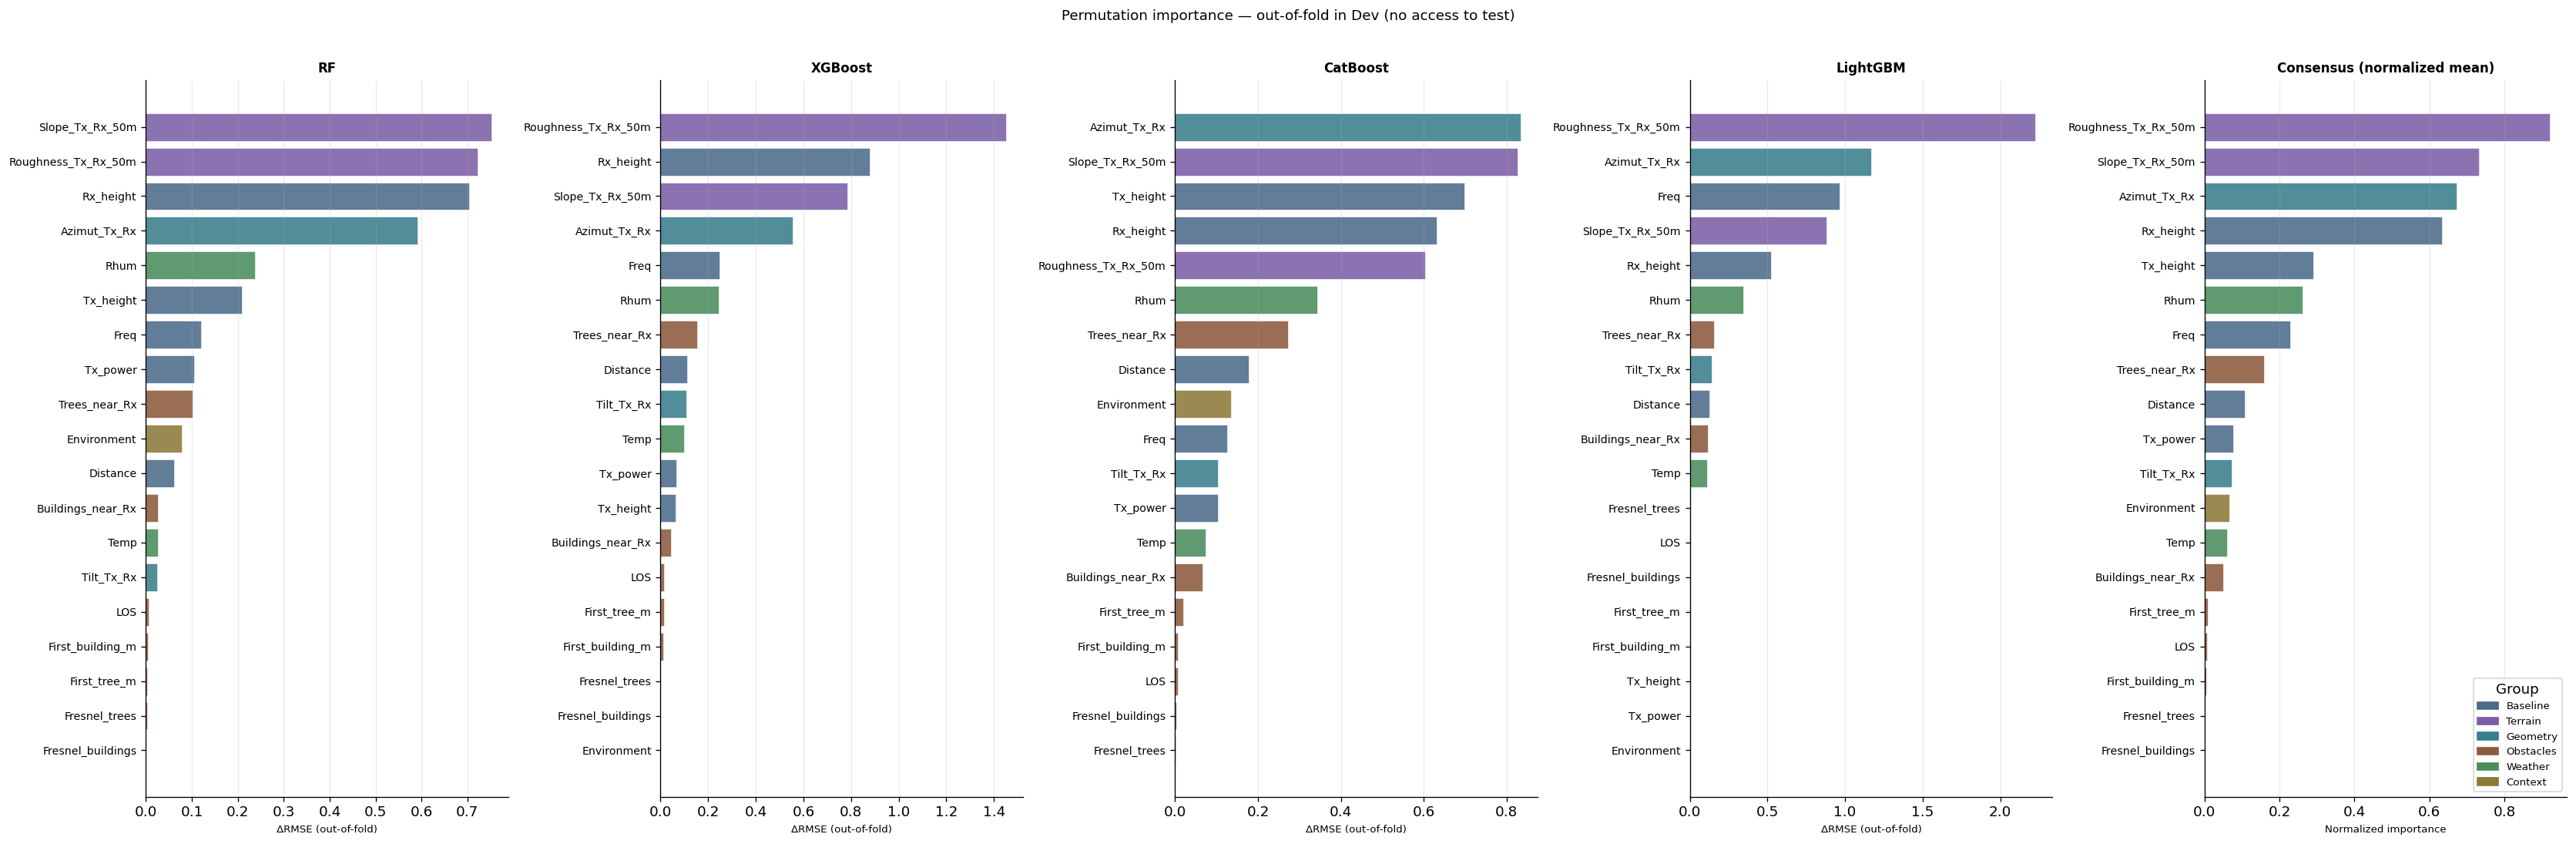

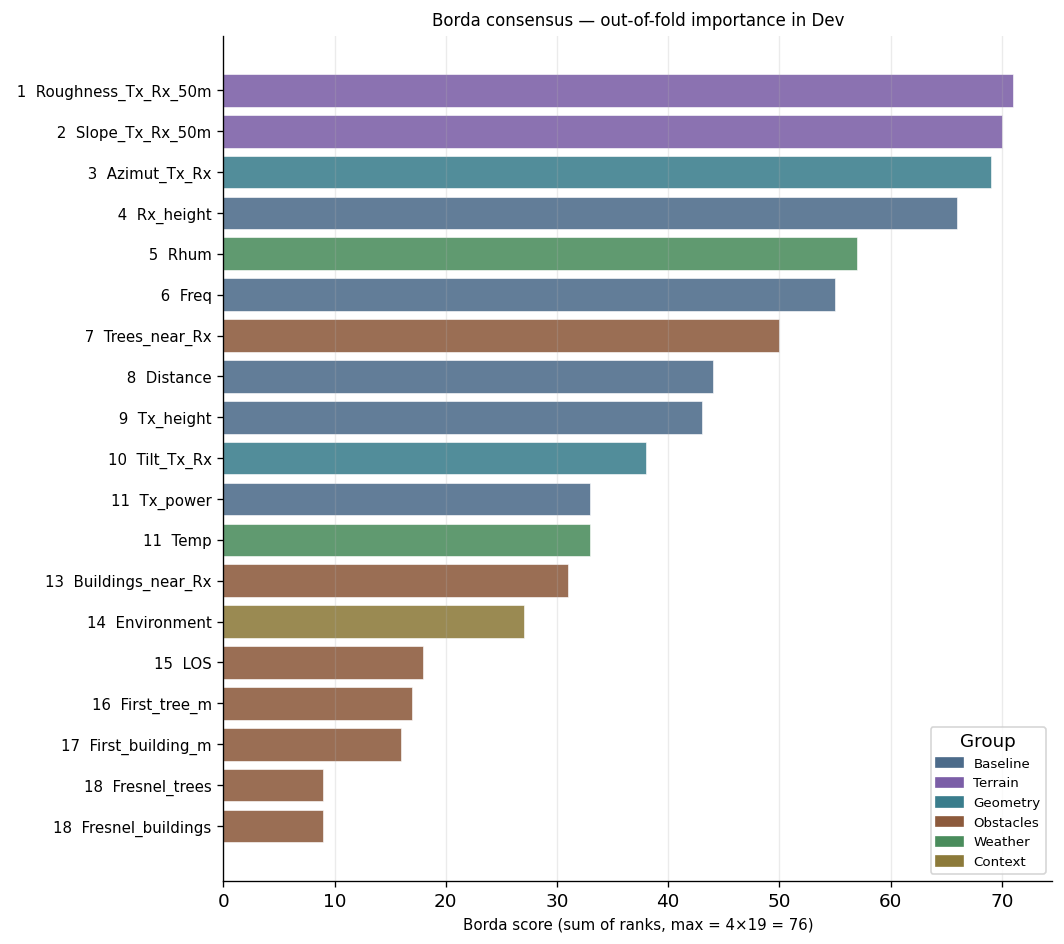

Figures sauvées → outputs_nb07/


In [14]:
# ── Figure : importances par modèle + consensus ──────────────────────────────
from matplotlib.patches import Patch
PERM_COLS = [f'Perm_{n}' for n in IMP_MODELS]
imp_norm = imp_multi[PERM_COLS].copy()
for c in PERM_COLS:
    mx = imp_norm[c].max()
    imp_norm[c] = imp_norm[c] / mx if mx > 0 else imp_norm[c]
imp_multi['Consensus'] = imp_norm.mean(axis=1)

panels = list(zip(PERM_COLS, IMP_MODELS)) + [('Consensus', 'Consensus (normalized mean)')]
fig, axes = plt.subplots(1, 5, figsize=(28, 9))
for ax, (col, label) in zip(axes, panels):
    order = imp_multi[col].sort_values(ascending=False).index.tolist()
    ax.barh(range(len(order)), [imp_multi.loc[f, col] for f in order],
            color=[GROUP_COLORS[feat_to_grp[f]] for f in order],
            edgecolor='white', linewidth=0.4, alpha=0.88)
    ax.set_yticks(range(len(order))); ax.set_yticklabels(order, fontsize=8.5)
    ax.invert_yaxis()
    ax.set_xlabel('ΔRMSE (out-of-fold)' if col != 'Consensus' else 'Normalized importance', fontsize=8)
    ax.set_title(label, fontsize=10, fontweight='bold')
    ax.grid(axis='x', alpha=0.25)
axes[-1].legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLORS.items()],
                fontsize=8, loc='lower right', title='Group')
plt.suptitle('Permutation importance — out-of-fold in Dev (no access to test)',
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig(OUT / 'fig_perm_importance_dev.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_perm_importance_dev.png', dpi=150, bbox_inches='tight')
plt.show()

fig, ax = plt.subplots(figsize=(9, 8))
order = imp_multi.sort_values('Borda_score', ascending=False).index.tolist()
ax.barh(range(len(order)), [imp_multi.loc[f, 'Borda_score'] for f in order],
        color=[GROUP_COLORS[feat_to_grp[f]] for f in order],
        edgecolor='white', linewidth=0.4, alpha=0.88)
ax.set_yticks(range(len(order)))
ax.set_yticklabels([f'{int(imp_multi.loc[f, "Borda_rank"]):2d}  {f}' for f in order], fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('Borda score (sum of ranks, max = 4×19 = 76)', fontsize=9)
ax.set_title('Borda consensus — out-of-fold importance in Dev', fontsize=10)
ax.grid(axis='x', alpha=0.25)
ax.legend(handles=[Patch(color=c, label=g) for g, c in GROUP_COLORS.items()],
          fontsize=8, loc='lower right', title='Group')
plt.tight_layout()
plt.savefig(OUT / 'fig_borda_rank_dev.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_borda_rank_dev.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figures sauvées → outputs_nb07/')

---
## §5 — Ablation cumulative et choix de N\*

Les features sont ajoutées une à une dans l'ordre de Borda. Pour chaque N, chaque modèle est évalué en **validation croisée répétée dans Dev** (5 plis × 2 répétitions), et non sur le test.

**Choix de N\* — règle du plateau à 1 erreur type.** Prendre l'`argmin` du RMSE réintroduirait un biais de sélection, même à l'intérieur de Dev. On retient donc le plus petit N dont le RMSE moyen reste sous *(meilleur RMSE + 1 erreur type du meilleur)* : c'est le modèle le plus parcimonieux qui n'est pas distinguable du meilleur.

In [15]:
rkf = RepeatedKFold(n_splits=ABL_SPLITS, n_repeats=ABL_REPEATS, random_state=SEED)
abl_folds = list(rkf.split(X_dev))
print(f'Ablation — {len(abl_folds)} estimations par point ({ABL_SPLITS} plis × {ABL_REPEATS} rép.)')

rows = []
for n in range(1, len(BORDA_ORDER) + 1):
    feats = BORDA_ORDER[:n]
    idx   = [ALL_FEATURES.index(f) for f in feats]
    row   = {'N_features': n, 'Feature_added': BORDA_ORDER[n - 1],
             'Cumulative_features': ', '.join(feats)}
    for mdl in IMP_MODELS:
        r_, s_ = [], []
        for tr, va in abl_folds:
            m = build_model(mdl)
            m.fit(X_dev[np.ix_(tr, idx)], y_dev[tr])
            p = m.predict(X_dev[np.ix_(va, idx)])
            r_.append(float(np.sqrt(mean_squared_error(y_dev[va], p))))
            s_.append(float(r2_score(y_dev[va], p)))
        row[f'RMSE_{mdl}']    = round(float(np.mean(r_)), 4)
        row[f'RMSEsd_{mdl}']  = round(float(np.std(r_, ddof=1)), 4)
        row[f'R2_{mdl}']      = round(float(np.mean(s_)), 4)
    rows.append(row)
    print(f'N={n:2d}  +{row["Feature_added"]:22s}  ' +
          '  '.join(f'{m}: {row[f"RMSE_{m}"]:.3f}±{row[f"RMSEsd_{m}"]:.2f}' for m in IMP_MODELS))

ablation_df = pd.DataFrame(rows)
ablation_df.to_csv(OUT / 'core_set_ablation_dev.csv', index=False)
print('\nSauvé → outputs_nb07/core_set_ablation_dev.csv')

Ablation — 10 estimations par point (5 plis × 2 rép.)


N= 1  +Roughness_Tx_Rx_50m     RF: 7.113±0.85  XGBoost: 6.983±0.73  CatBoost: 6.971±0.76  LightGBM: 6.887±0.63


N= 2  +Slope_Tx_Rx_50m         RF: 6.493±0.50  XGBoost: 6.865±0.65  CatBoost: 6.633±0.60  LightGBM: 6.969±0.65


N= 3  +Azimut_Tx_Rx            RF: 5.635±0.43  XGBoost: 6.423±0.67  CatBoost: 5.615±0.39  LightGBM: 5.932±0.46


N= 4  +Rx_height               RF: 5.598±0.43  XGBoost: 5.827±0.48  CatBoost: 5.514±0.41  LightGBM: 5.731±0.48


...

N=15  +LOS                     RF: 5.584±0.45  XGBoost: 5.553±0.52  CatBoost: 5.442±0.44  LightGBM: 5.590±0.64


N=16  +First_tree_m            RF: 5.593±0.49  XGBoost: 5.635±0.54  CatBoost: 5.470±0.44  LightGBM: 5.594±0.70


N=17  +First_building_m        RF: 5.609±0.44  XGBoost: 5.620±0.52  CatBoost: 5.476±0.43  LightGBM: 5.594±0.70


N=18  +Fresnel_trees           RF: 5.596±0.47  XGBoost: 5.631±0.52  CatBoost: 5.477±0.39  LightGBM: 5.598±0.65


N=19  +Fresnel_buildings       RF: 5.607±0.47  XGBoost: 5.639±0.50  CatBoost: 5.475±0.39  LightGBM: 5.598±0.65

Sauvé → outputs_nb07/core_set_ablation_dev.csv


In [16]:
# ── N* par la règle du plateau à 1 erreur type ───────────────────────────────
n_est = len(abl_folds)
NSTAR, nstar_rows = {}, []
for mdl in IMP_MODELS:
    means = ablation_df[f'RMSE_{mdl}'].values
    sds   = ablation_df[f'RMSEsd_{mdl}'].values
    j     = int(np.argmin(means))
    se    = sds[j] / np.sqrt(n_est)
    thr   = means[j] + se
    n_star = int(ablation_df['N_features'].values[np.argmax(means <= thr)])
    NSTAR[mdl] = n_star
    nstar_rows.append({
        'Model': mdl,
        'N_argmin': int(ablation_df['N_features'].values[j]),
        'RMSE_argmin': round(float(means[j]), 4),
        'SE': round(float(se), 4),
        'Seuil_1SE': round(float(thr), 4),
        'N*': n_star,
        'RMSE_dev_a_Nstar': round(float(means[n_star - 1]), 4),
    })

nstar_df = pd.DataFrame(nstar_rows)
nstar_df.to_csv(OUT / 'nstar_selection_dev.csv', index=False)
print('=== Choix de N* — règle du plateau à 1 erreur type (validation dans Dev) ===')
print(nstar_df.to_string(index=False))
print()
for mdl in IMP_MODELS:
    print(f'{mdl:10s} N*={NSTAR[mdl]:2d} : {BORDA_ORDER[:NSTAR[mdl]]}')

=== Choix de N* — règle du plateau à 1 erreur type (validation dans Dev) ===
   Model  N_argmin  RMSE_argmin     SE  Seuil_1SE  N*  RMSE_dev_a_Nstar
      RF         6       5.4779 0.1495     5.6274   4            5.5981
 XGBoost        15       5.5534 0.1648     5.7182   5            5.6550
CatBoost         6       5.3683 0.1529     5.5212   4            5.5136
LightGBM         6       5.4818 0.1992     5.6810   5            5.5017

RF         N*= 4 : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height']
XGBoost    N*= 5 : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum']
CatBoost   N*= 4 : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height']
LightGBM   N*= 5 : ['Roughness_Tx_Rx_50m', 'Slope_Tx_Rx_50m', 'Azimut_Tx_Rx', 'Rx_height', 'Rhum']


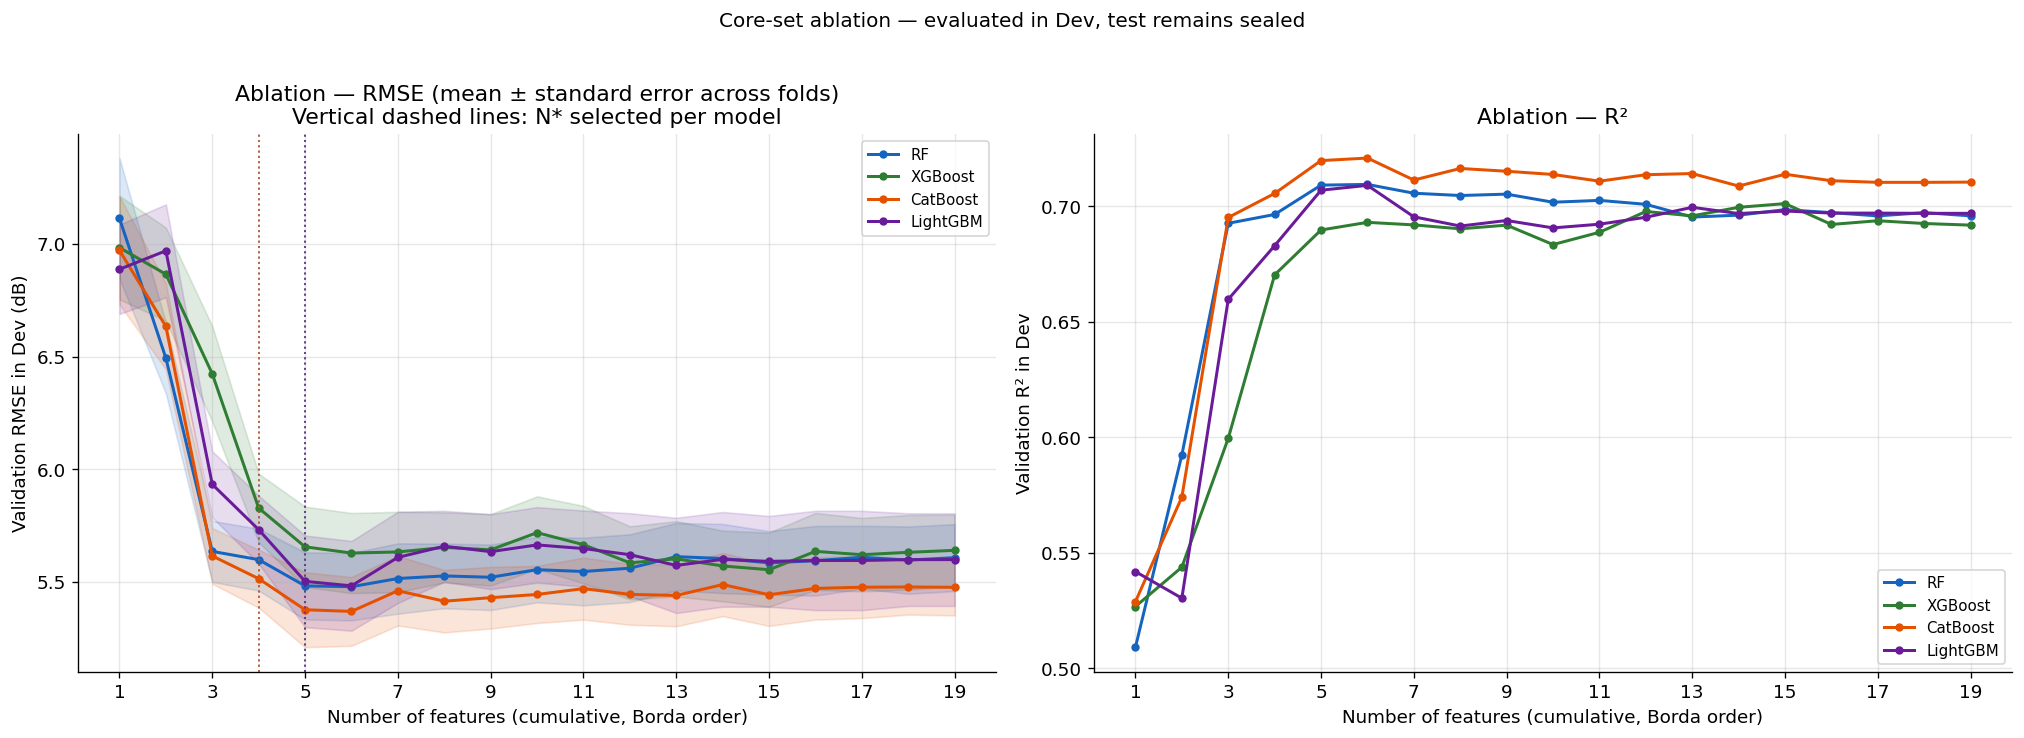

Sauvé → outputs_nb07/fig_core_set_ablation_dev.*


In [17]:
# ── Figure : courbes d'ablation avec bande d'incertitude ─────────────────────
ABL_COLORS = {'RF': '#1565C0', 'XGBoost': '#2E7D32', 'CatBoost': '#E65100', 'LightGBM': '#6A1B9A'}
fig, axes = plt.subplots(1, 2, figsize=(17, 6))
N = ablation_df['N_features']

for mdl, c in ABL_COLORS.items():
    mu = ablation_df[f'RMSE_{mdl}']
    se = ablation_df[f'RMSEsd_{mdl}'] / np.sqrt(n_est)
    axes[0].plot(N, mu, marker='o', color=c, lw=1.8, label=mdl, markersize=4)
    axes[0].fill_between(N, mu - se, mu + se, color=c, alpha=0.15)
    axes[0].axvline(NSTAR[mdl], color=c, ls=':', lw=1.2, alpha=0.7)
    axes[1].plot(N, ablation_df[f'R2_{mdl}'], marker='o', color=c, lw=1.8, label=mdl, markersize=4)

axes[0].set_xlabel("Number of features (cumulative, Borda order)")
axes[0].set_ylabel('Validation RMSE in Dev (dB)')
axes[0].set_title("Ablation — RMSE (mean ± standard error across folds)\nVertical dashed lines: N* selected per model")
axes[1].set_xlabel("Number of features (cumulative, Borda order)")
axes[1].set_ylabel('Validation R² in Dev')
axes[1].set_title('Ablation — R²')
for ax in axes:
    ax.set_xticks(N[::2]); ax.legend(fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Core-set ablation — evaluated in Dev, test remains sealed', fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(OUT / 'fig_core_set_ablation_dev.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_core_set_ablation_dev.png', dpi=150, bbox_inches='tight')
plt.show()
print('Sauvé → outputs_nb07/fig_core_set_ablation_dev.*')

---
## §6 — Évaluation finale sur le test

Première et unique lecture du test. Chaque modèle est réentraîné sur **tout Dev** avec les N\* features retenues au §5, puis évalué une fois.

On rapporte le RMSE et le R² **globalement et par environnement**, plus deux lignes de base triviales. Sur un jeu bimodal, un R² global peut être porté par l'écart entre villes plutôt que par la modélisation de la propagation : la ventilation le rend visible.

In [18]:
final_rows, final_preds = [], {}
for mdl in IMP_MODELS:
    feats = BORDA_ORDER[:NSTAR[mdl]]
    idx   = [ALL_FEATURES.index(f) for f in feats]
    m = build_model(mdl)
    m.fit(X_dev[:, idx], y_dev)              # tout Dev
    pred = m.predict(X_test[:, idx])         # ← unique lecture du test
    final_preds[mdl] = pred
    rec = {'Model': mdl, 'N*': NSTAR[mdl], **evaluate(y_test, pred)}
    for env, lbl in [(1, 'Urbain'), (0, 'Suburbain')]:
        msk = env_test == env
        rec[f'RMSE_{lbl}'] = round(float(np.sqrt(mean_squared_error(y_test[msk], pred[msk]))), 3)
        rec[f'R2_{lbl}']   = round(float(r2_score(y_test[msk], pred[msk])), 3)
    final_rows.append(rec)

# ── Lignes de base triviales ────────────────────────────────────────────────
pred_gm = np.full_like(y_test, y_dev.mean())
rec = {'Model': 'Base : moyenne globale', 'N*': 0, **evaluate(y_test, pred_gm)}
for env, lbl in [(1, 'Urbain'), (0, 'Suburbain')]:
    msk = env_test == env
    rec[f'RMSE_{lbl}'] = round(float(np.sqrt(mean_squared_error(y_test[msk], pred_gm[msk]))), 3)
    rec[f'R2_{lbl}']   = round(float(r2_score(y_test[msk], pred_gm[msk])), 3)
final_rows.append(rec)

city_mean = {e: y_dev[env_dev == e].mean() for e in (0, 1)}
pred_cm   = np.array([city_mean[e] for e in env_test])
rec = {'Model': 'Base : moyenne par ville', 'N*': 0, **evaluate(y_test, pred_cm)}
for env, lbl in [(1, 'Urbain'), (0, 'Suburbain')]:
    msk = env_test == env
    rec[f'RMSE_{lbl}'] = round(float(np.sqrt(mean_squared_error(y_test[msk], pred_cm[msk]))), 3)
    rec[f'R2_{lbl}']   = round(float(r2_score(y_test[msk], pred_cm[msk])), 3)
final_rows.append(rec)

final_df = pd.DataFrame(final_rows)
for c in ['RMSE', 'MAE', 'Bias']: final_df[c] = final_df[c].round(3)
final_df['R2'] = final_df['R2'].round(3)
final_df = final_df[['Model', 'N*', 'RMSE', 'MAE', 'R2', 'Bias',
                     'RMSE_Urbain', 'R2_Urbain', 'RMSE_Suburbain', 'R2_Suburbain']]
final_df.to_csv(OUT / 'final_test_results.csv', index=False)

print('=== ÉVALUATION FINALE SUR LE TEST (n={}) — une seule lecture ==='.format(len(y_test)))
print(final_df.to_string(index=False))
print()
print(f'Rappel : écart-type de E_field sur le test = {y_test.std():.2f} dB')
print(f'  urbain n={int((env_test==1).sum())}, std={y_test[env_test==1].std():.2f} dB')
print(f'  suburbain n={int((env_test==0).sum())}, std={y_test[env_test==0].std():.2f} dB')
print('\nSauvé → outputs_nb07/final_test_results.csv')

=== ÉVALUATION FINALE SUR LE TEST (n=66) — une seule lecture ===
                   Model  N*  RMSE   MAE     R2   Bias  RMSE_Urbain  R2_Urbain  RMSE_Suburbain  R2_Suburbain
                      RF   4 4.846 4.064  0.760  0.427        5.325      0.567           3.789         0.295
                 XGBoost   5 4.960 4.018  0.749  0.704        5.529      0.533           3.669         0.339
                CatBoost   4 5.195 4.311  0.724  0.634        5.813      0.484           3.777         0.299
                LightGBM   5 4.884 3.966  0.756  0.628        5.494      0.539           3.467         0.410
  Base : moyenne globale   0 9.898 8.770 -0.001 -0.236        9.428     -0.358          10.722        -4.645
Base : moyenne par ville   0 7.093 5.648  0.486 -0.361        8.135     -0.011           4.545        -0.014

Rappel : écart-type de E_field sur le test = 9.90 dB
  urbain n=43, std=8.09 dB
  suburbain n=23, std=4.51 dB

Sauvé → outputs_nb07/final_test_results.csv


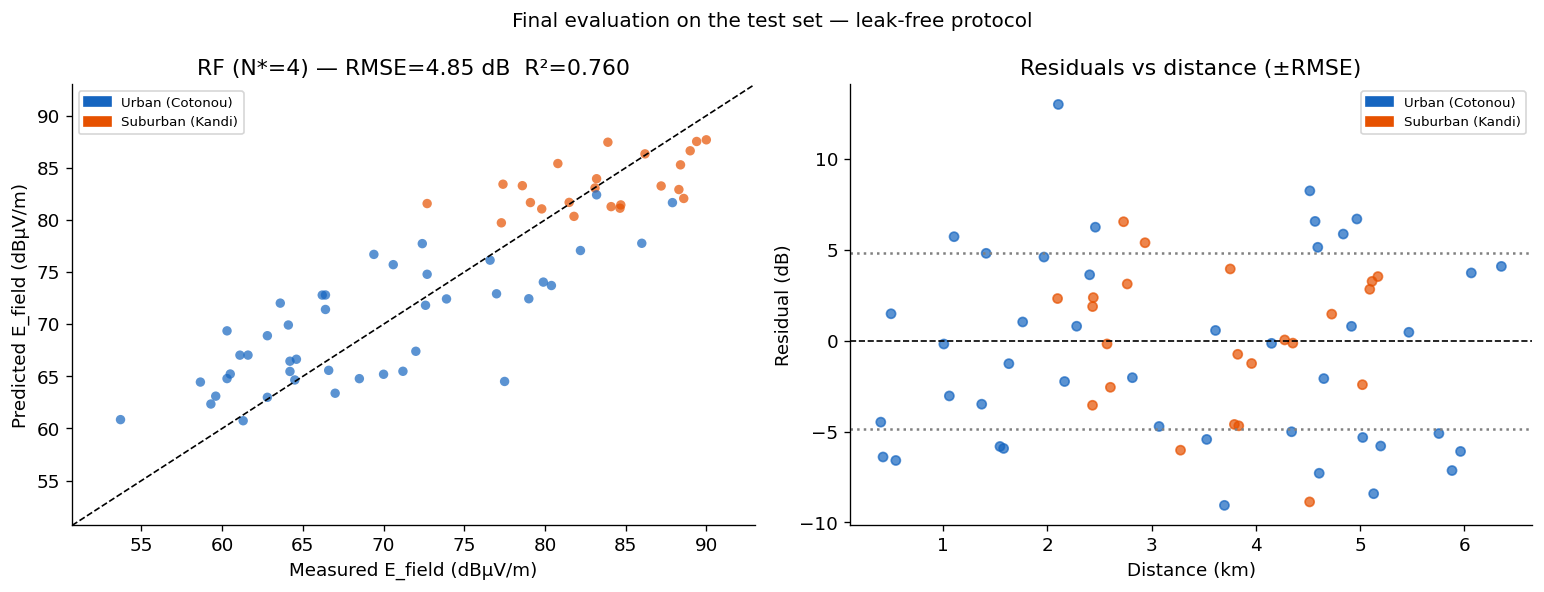

In [19]:
# ── Figure : prédit vs mesuré, meilleur modèle ───────────────────────────────
best = final_df[final_df['N*'] > 0].sort_values('RMSE').iloc[0]
bn   = best['Model']; pred = final_preds[bn]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors = ['#1565C0' if e == 1 else '#E65100' for e in env_test]
lims = [min(y_test.min(), pred.min()) - 3, max(y_test.max(), pred.max()) + 3]
axes[0].scatter(y_test, pred, c=colors, alpha=0.7, s=32, edgecolors='none')
axes[0].plot(lims, lims, 'k--', lw=1)
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel('Measured E_field (dBµV/m)'); axes[0].set_ylabel('Predicted E_field (dBµV/m)')
axes[0].set_title(f"{bn} (N*={int(best['N*'])}) — RMSE={best['RMSE']:.2f} dB  R²={best['R2']:.3f}")
from matplotlib.patches import Patch
h = [Patch(color='#1565C0', label='Urban (Cotonou)'), Patch(color='#E65100', label='Suburban (Kandi)')]
axes[0].legend(handles=h, fontsize=8)

axes[1].scatter(test_df['Distance'] / 1000, y_test - pred, c=colors, alpha=0.7, s=30)
axes[1].axhline(0, color='k', ls='--', lw=1)
axes[1].axhline(best['RMSE'], color='gray', ls=':'); axes[1].axhline(-best['RMSE'], color='gray', ls=':')
axes[1].set_xlabel('Distance (km)'); axes[1].set_ylabel('Residual (dB)')
axes[1].set_title('Residuals vs distance (±RMSE)')
axes[1].legend(handles=h, fontsize=8)
plt.suptitle('Final evaluation on the test set — leak-free protocol', fontsize=12)
plt.tight_layout()
plt.savefig(OUT / 'fig_final_test.pdf', bbox_inches='tight')
plt.savefig(OUT / 'fig_final_test.png', dpi=150, bbox_inches='tight')
plt.show()

---
## §7 — Quantification de la fuite

Le protocole d'origine (importance et ablation mesurées sur le test, N\* = `argmin` du RMSE de test) est rejoué **sur les mêmes 327 mesures et le même split**. L'écart avec le §6 mesure donc l'effet du protocole seul, sans mélange avec le changement de dataset.

In [20]:
# ── Protocole d'origine rejoué : importance ET ablation sur le test ──────────
imp_leak = pd.DataFrame(index=IMP_FEATS)
for name in IMP_MODELS:
    m = build_model(name)
    m.fit(X_dev[:, FEAT_IDX], y_dev)
    pr = permutation_importance(m, X_test[:, FEAT_IDX], y_test,
                                n_repeats=PERM_REPEATS, random_state=SEED, n_jobs=-1,
                                scoring='neg_root_mean_squared_error')
    imp_leak[f'Perm_{name}'] = np.clip(pr.importances_mean, 0, None)

rc = []
for col in [f'Perm_{n}' for n in IMP_MODELS]:
    imp_leak[f'R_{col}'] = imp_leak[col].rank(ascending=True, method='average').astype(int)
    rc.append(f'R_{col}')
imp_leak['Borda_score'] = imp_leak[rc].sum(axis=1)
imp_leak['Borda_rank']  = imp_leak['Borda_score'].rank(ascending=False, method='average').astype(int)

BORDA_LEAK = []
for rank in sorted(imp_leak['Borda_rank'].unique()):
    g = imp_leak[imp_leak['Borda_rank'] == rank].index.tolist()
    if len(g) > 1:
        g = [f for f in TIE_BREAK_ORDER if f in g] + [f for f in g if f not in TIE_BREAK_ORDER]
    BORDA_LEAK.extend(g)

rows_leak = []
for n in range(1, 20):
    idx = [ALL_FEATURES.index(f) for f in BORDA_LEAK[:n]]
    r = {'N_features': n}
    for mdl in IMP_MODELS:
        m = build_model(mdl); m.fit(X_dev[:, idx], y_dev)
        p = m.predict(X_test[:, idx])
        r[f'RMSE_{mdl}'] = round(float(np.sqrt(mean_squared_error(y_test, p))), 4)
        r[f'R2_{mdl}']   = round(float(r2_score(y_test, p)), 4)
    rows_leak.append(r)
abl_leak = pd.DataFrame(rows_leak)
abl_leak.to_csv(OUT / 'ablation_ancien_protocole.csv', index=False)

cmp_rows = []
for mdl in IMP_MODELS:
    j  = int(abl_leak[f'RMSE_{mdl}'].idxmin())
    nl = int(abl_leak.loc[j, 'N_features'])
    clean = final_df[final_df['Model'] == mdl].iloc[0]
    cmp_rows.append({
        'Model': mdl,
        'N*_ancien': nl, 'RMSE_ancien': abl_leak.loc[j, f'RMSE_{mdl}'], 'R2_ancien': abl_leak.loc[j, f'R2_{mdl}'],
        'N*_propre': int(clean['N*']), 'RMSE_propre': clean['RMSE'], 'R2_propre': clean['R2'],
        'Biais_optimiste_RMSE': round(float(clean['RMSE'] - abl_leak.loc[j, f'RMSE_{mdl}']), 3),
    })
cmp_df = pd.DataFrame(cmp_rows)
cmp_df.to_csv(OUT / 'comparaison_protocoles.csv', index=False)

print('=== Ancien protocole (sélection sur le test) vs protocole sans fuite ===')
print('Mêmes 327 mesures, même split — seul le protocole change.\n')
print(cmp_df.to_string(index=False))
print()
print('Biais optimiste = RMSE_propre − RMSE_ancien : de combien le protocole')
print("d'origine sous-estimait l'erreur réelle du modèle.")
print()
print('Ordre de Borda — ancien (test) vs nouveau (out-of-fold Dev) :')
for i, (a, b) in enumerate(zip(BORDA_LEAK, BORDA_ORDER), 1):
    flag = '' if a == b else '   ← diffère'
    print(f'  {i:2d}. {a:22s} | {b:22s}{flag}')

=== Ancien protocole (sélection sur le test) vs protocole sans fuite ===
Mêmes 327 mesures, même split — seul le protocole change.

   Model  N*_ancien  RMSE_ancien  R2_ancien  N*_propre  RMSE_propre  R2_propre  Biais_optimiste_RMSE
      RF         11       4.4866     0.7944          4        4.846      0.760                 0.359
 XGBoost         13       4.3395     0.8077          5        4.960      0.749                 0.620
CatBoost         14       4.6354     0.7806          4        5.195      0.724                 0.560
LightGBM          9       4.7115     0.7733          5        4.884      0.756                 0.173

Biais optimiste = RMSE_propre − RMSE_ancien : de combien le protocole
d'origine sous-estimait l'erreur réelle du modèle.

Ordre de Borda — ancien (test) vs nouveau (out-of-fold Dev) :
   1. Slope_Tx_Rx_50m        | Roughness_Tx_Rx_50m      ← diffère
   2. Roughness_Tx_Rx_50m    | Slope_Tx_Rx_50m          ← diffère
   3. Azimut_Tx_Rx           | Azimut_Tx_Rx   

---
## §8 — Ce qu'il reste à faire

Les notebooks 03 (calibration Hata), 04 (hybrides A1/A2) et 06 (comparaison inter-familles) se branchent sur ce protocole sans autre changement : ils consomment `BORDA_ORDER` et les `N*` du §5 au lieu de ceux issus du test, et leur évaluation finale se fait sur le même test scellé, filtré à d ≥ 1 km.

La calibration Hata était déjà estimée sur le train seul — elle devient « estimée sur Dev », sans autre modification.

Le notebook 05 (augmentation) n'a pas besoin d'être refait : le notebook 06 a déjà établi que le gain de CTGAN n'était pas reproductible une fois la graine fixée, et la ligne a été retirée du tableau final.
